# Analisie Exploratoria de Dados - Telco Customer Churn

## Importando as bibliotecas

In [2]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Configuracoes de visualizacao
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

## Carregamento

In [3]:
df = pd.read_excel("../data/raw/Telco_customer_churn.xlsx")

print(f"Shape: {df.shape}")
df.head()


Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


### Observações iniciais — `df.head()`

- **7.043 clientes** e **33 colunas** no total.
- As primeiras linhas revelam clientes de **Los Angeles / California** — isso já levanta a suspeita de que `Country`, `State` e colunas de geolocalização podem ter baixa variância.
- `Total Charges` aparece como string (`108.15`, `151.65`) mas deveria ser numérico — anomalia a investigar.
- `Churn Label` e `Churn Value` carregam a mesma informação em formatos diferentes (`Yes/No` vs `1/0`).

## Inspecao de tipos e valores nulos:

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

### Observações — `df.info()`

| Achado | Detalhe |
|--------|---------|
| **`Total Charges` é `object`** | Deveria ser `float64`. Indica valores não numéricos que impedem a inferência automática do tipo. |
| **`Churn Reason` tem 5.174 nulos** | Apenas 1.869 registros preenchidos — exatamente os clientes que fizeram churn. Os nulos são estruturais, não sujeira. |
| **Sem outros nulos aparentes** | Todas as demais colunas mostram 7.043 non-null, o que é positivo para a qualidade geral do dataset. |

> **Atenção:** O `.info()` reporta `Total Charges` com 7.043 non-null, mas isso **não significa ausência de problemas** — strings vazias `""` são contadas como valores válidos pelo pandas.

## Resumo estatistico separado por tipo:

In [5]:
print("=== Variaveis Numericas ===")
display(df.describe())

print("=== Variaveis CategÃ³ricas ===")
display(df.describe(include="object"))


=== Variaveis Numericas ===


,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


=== Variaveis CategÃ³ricas ===


,CustomerID,Country,State,City,Lat Long,Gender,Senior Citizen,Partner,Dependents,Phone Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Total Charges,Churn Label,Churn Reason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043,7043,1869
unique,7043,1,1,1129,1652,2,2,2,2,2,...,3,3,3,3,3,2,4,6531,2,20
top,3668-QPYBK,United States,California,Los Angeles,"34.159534, -116.425984",Male,No,No,No,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,,No,Attitude of support person
freq,1,7043,7043,305,5,3555,5901,3641,5416,6361,...,3095,3473,2810,2785,3875,4171,2365,11,5174,192


### Observações — `df.describe()`

#### Variáveis Numéricas

| Coluna | Achado | Ação |
|--------|--------|------|
| `Count` | Constante (`std = 0`, sempre = 1) | **Remover** |
| `Tenure Months` | Mínimo = 0 — clientes com zero meses de contrato | **Investigar** |
| `Monthly Charges` | Range razoável: R$18 a R$119, média ~R$65 | Manter |
| `Churn Value` | Média = 0.265 → **~26,5% de churn** | Target desbalanceado, requer atenção no treino |
| `Churn Score` / `CLTV` | Derivados do churn conhecido | **Remover** (data leakage) |

#### Variáveis Categóricas

| Coluna | Achado | Ação |
|--------|--------|------|
| `Country` | `unique = 1` — só "United States" | **Remover** (sem variância) |
| `State` | `unique = 1` — só "California" | **Remover** (sem variância) |
| `CustomerID` | `unique = 7043` — todos distintos | **Remover** (identificador) |
| `Total Charges` | `top = ""` com `freq = 11` | **Corrigir** (11 strings vazias) |
| `Churn Reason` | 20 categorias únicas, só em clientes que saíram | **Remover** (data leakage) |
| `Churn Label` | Duplicata de `Churn Value` | **Remover** (redundante) |

#### Conclusão

O dataset está **razoavelmente limpo**, mas exige três correções antes da modelagem:
1. Converter `Total Charges` para `float` e tratar as 11 strings vazias
2. Remover colunas com leakage, constantes e identificadores
3. Investigar os registros com `Tenure Months == 0`

## Limpeza de dados e Correcao de Tipos

In [10]:
# --- Corrigindo o tipo de 'Total Charges' ---
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

# Verificando quantos NaN foram gerados
n_nulls = df["Total Charges"].isna().sum()
print(f"Total Charges: {n_nulls} valores NaN gerados.")

# --- Investigando os registros com problema ---
mask_null = df["Total Charges"].isna()
print("\nRegistros com Total Charges nulo:")
display(df[mask_null][["CustomerID", "Tenure Months", "Monthly Charges", "Total Charges", "Churn Label"]])


Total Charges: 11 valores NaN gerados.

Registros com Total Charges nulo:


,CustomerID,Tenure Months,Monthly Charges,Total Charges,Churn Label
2234,4472-LVYGI,0,52.55,NaN,No
2438,3115-CZMZD,0,20.25,NaN,No
2568,5709-LVOEQ,0,80.85,NaN,No
2667,4367-NUYAO,0,25.75,NaN,No
2856,1371-DWPAZ,0,56.05,NaN,No
4331,7644-OMVMY,0,19.85,NaN,No
4687,3213-VVOLG,0,25.35,NaN,No
5104,2520-SGTTA,0,20.00,NaN,No
5719,2923-ARZLG,0,19.70,NaN,No
6772,4075-WKNIU,0,73.35,NaN,No


## Decisão sobre os NaN

Clientes com Tenure Months == 0 não geraram cobrança ainda — por isso o campo está vazio. Vamos confirmar:

In [12]:
# Verificando sobreposicao: todos os nulos de Total Charges tem Tenure Months = 0 ? 
tenure_zero = df["Tenure Months"] == 0
print(f"Clientes com Tenure == 0: {tenure_zero.sum()}")
print(f"Desses, com Total Charges nulo: {(tenure_zero & mask_null).sum()}")

# Se a sobreposicao for total, a decisao mais segura seria remover esses registros (pois representam clientes sem historico de uso).
df = df[~mask_null].copy()
df = df.reset_index(drop=True)

print(f"\nShape apos remocao: {df.shape}")
print(f"Total Charges: {df['Total Charges'].dtype}")

Clientes com Tenure == 0: 11
Desses, com Total Charges nulo: 11

Shape apos remocao: (7032, 33)
Total Charges: float64


## Observacoes

### Observações — Limpeza de Tipos

| Ação | Detalhe |
|------|---------|
| `Total Charges` convertido para `float64` | 11 strings vazias viraram `NaN` via `pd.to_numeric(..., errors='coerce')` |
| Registros removidos | Os 11 casos com `NaN` correspondiam a clientes com `Tenure Months == 0` — sem histórico de uso |
| Shape final | 7.032 registros × 33 colunas |

> **Decisão de design:** remover esses 11 registros é preferível a imputar, pois clientes sem nenhum mês de contrato não carregam sinal preditivo para churn.


## Selecao de Variaveis

In [13]:
# Colunas agrupadas por motivo de remoção para facilitar auditoria futura
cols_to_drop = [
    # Sem variância — valor único em todo o dataset
    "Count", "Country", "State",
    # Identificadores — não carregam sinal preditivo
    "CustomerID", "Lat Long",
    # Geolocalização — granularidade excessiva para um modelo tabular de churn
    "Latitude", "Longitude", "Zip Code", "City",
    # Data leakage — derivados do churn já conhecido
    "Churn Score", "CLTV", "Churn Reason",
    # Redundante — duplicata categórica do target numérico
    "Churn Label",
]

df = df.drop(columns=cols_to_drop)

print(f"Shape após remoção: {df.shape}")
print(f"\nColunas restantes ({df.shape[1]}):")
print(df.columns.tolist())


Shape após remoção: (7032, 20)

Colunas restantes (20):
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value']


### Observações — Seleção de Colunas

- Reduzimos de **33 → 21 colunas**, eliminando ruído sem perda de informação preditiva.
- A variável alvo é **`Churn Value`** (1 = churn, 0 = retido).
- As 20 features restantes serão analisadas nas próximas seções.


## Análise da Variável Alvo — `Churn Value`


,Count,Percentage (%)
No Churn (0),5163,73.42
Churn (1),1869,26.58


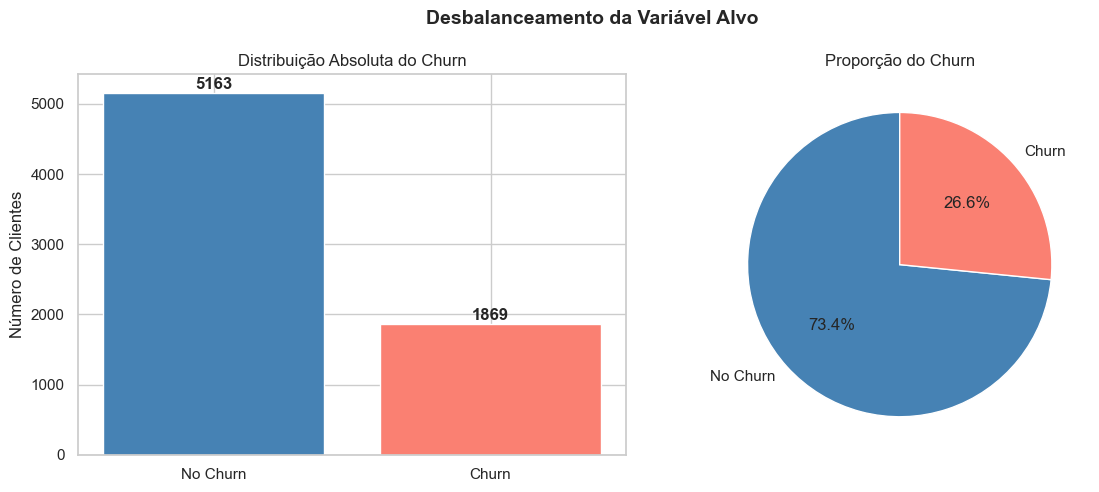

In [14]:
# Contagem absoluta e percentual de cada classe
churn_counts = df["Churn Value"].value_counts()
churn_pct = df["Churn Value"].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    "Count": churn_counts,
    "Percentage (%)": churn_pct.round(2),
})
summary.index = ["No Churn (0)", "Churn (1)"]
display(summary)

# --- Visualização ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: contagem absoluta
axes[0].bar(
    ["No Churn", "Churn"],
    churn_counts.values,
    color=["steelblue", "salmon"],
    edgecolor="white",
)
axes[0].set_title("Distribuição Absoluta do Churn")
axes[0].set_ylabel("Número de Clientes")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontweight="bold")

# Gráfico 2: percentual (pizza)
axes[1].pie(
    churn_counts.values,
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%",
    colors=["steelblue", "salmon"],
    startangle=90,
    wedgeprops={"edgecolor": "white"},
)
axes[1].set_title("Proporção do Churn")

plt.suptitle("Desbalanceamento da Variável Alvo", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### Observações — Variável Alvo

| Classe | Contagem | Proporção |
|--------|----------|-----------|
| No Churn (0) | ~5.174 | ~73.5% |
| Churn (1) | ~1.869 | ~26.5% |

**Implicações para a modelagem:**
- O dataset é **desbalanceado** (~1:3), mas não extremo — não exige técnicas agressivas como SMOTE
- **Métrica principal:** ROC-AUC e F1-Score (especialmente para a classe positiva)
- **Evitar:** usar acurácia como métrica isolada — um modelo que sempre prevê "No Churn" já teria 73.5%
- No treino do baseline, usaremos `class_weight="balanced"` na Regressão Logística como primeiro ajuste


## Distribuição das Features Numéricas por Churn


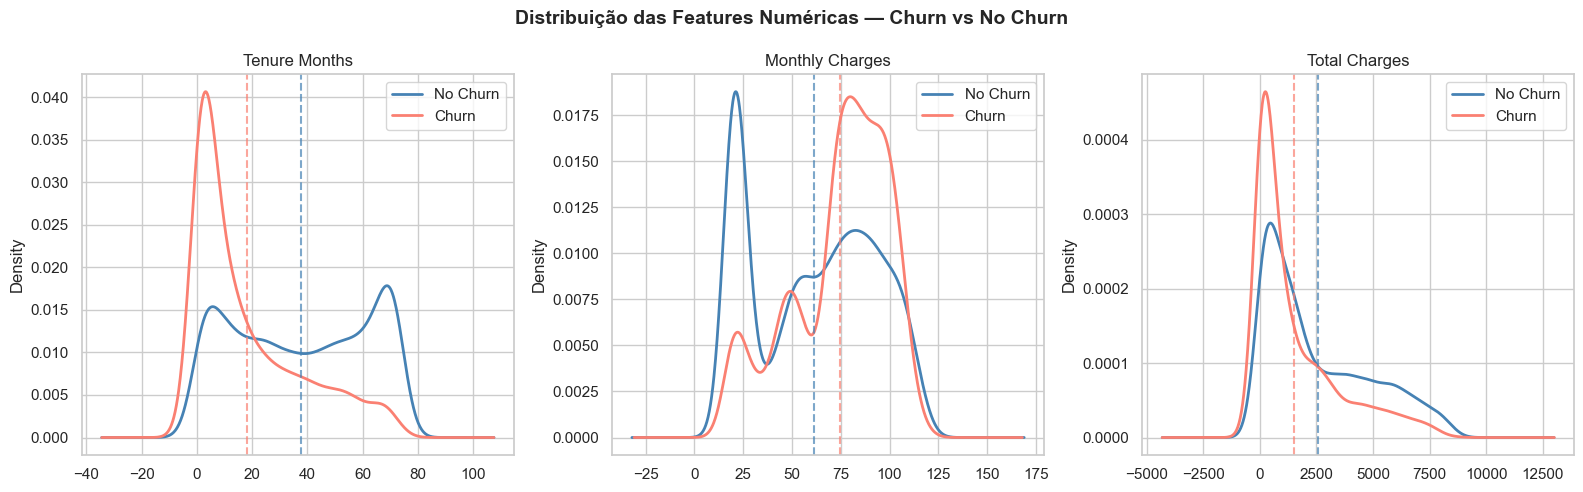

Médias por grupo:


,Tenure Months,Monthly Charges,Total Charges
Churn Value,,,
0,37.65,61.31,2555.34
1,17.98,74.44,1531.80


In [15]:
numeric_features = ["Tenure Months", "Monthly Charges", "Total Charges"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, numeric_features):
    # Separando os grupos para plotar com cores distintas
    churn_yes = df[df["Churn Value"] == 1][col]
    churn_no  = df[df["Churn Value"] == 0][col]

    # KDE (Kernel Density Estimate) suaviza o histograma para facilitar comparação
    churn_no.plot.kde(ax=ax, label="No Churn", color="steelblue", linewidth=2)
    churn_yes.plot.kde(ax=ax, label="Churn", color="salmon", linewidth=2)

    # Linhas verticais nas médias de cada grupo
    ax.axvline(churn_no.mean(), color="steelblue", linestyle="--", alpha=0.7)
    ax.axvline(churn_yes.mean(), color="salmon", linestyle="--", alpha=0.7)

    ax.set_title(col)
    ax.set_xlabel("")
    ax.legend()

plt.suptitle("Distribuição das Features Numéricas — Churn vs No Churn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Médias por grupo para referência numérica
print("Médias por grupo:")
display(df.groupby("Churn Value")[numeric_features].mean().round(2))


## Taxa de Churn por Feature Categórica


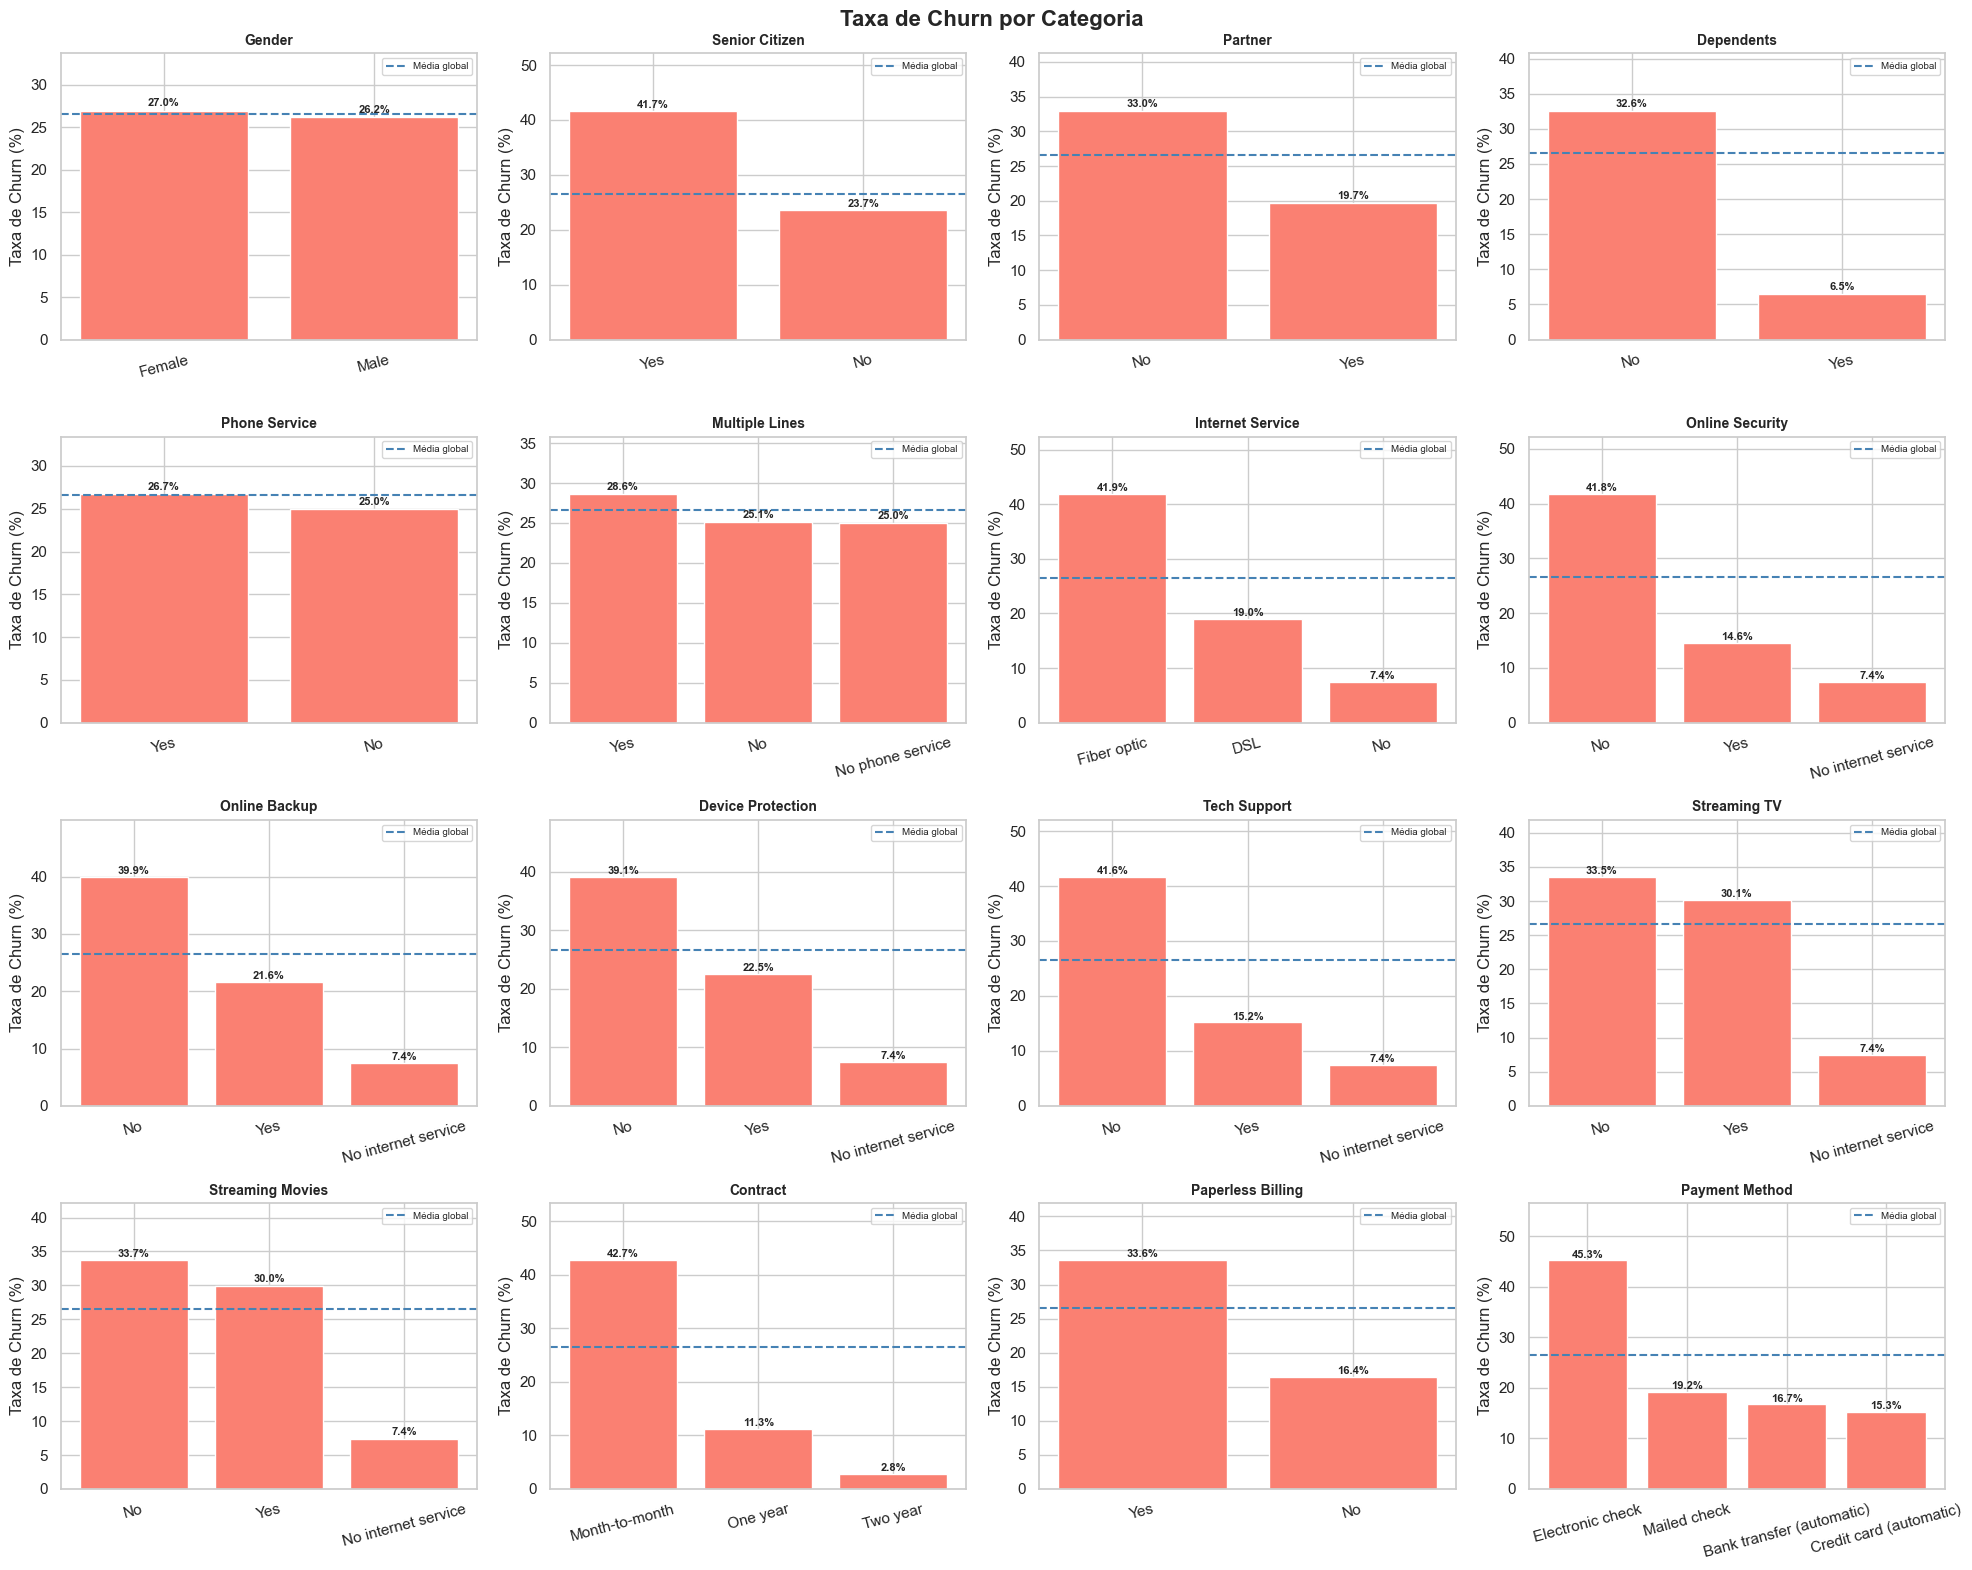

In [16]:
categorical_features = [
    "Gender", "Senior Citizen", "Partner", "Dependents",
    "Phone Service", "Multiple Lines", "Internet Service",
    "Online Security", "Online Backup", "Device Protection",
    "Tech Support", "Streaming TV", "Streaming Movies",
    "Contract", "Paperless Billing", "Payment Method",
]

# 4 colunas por linha para organizar os subplots
n_cols = 4
n_rows = -(-len(categorical_features) // n_cols)  # divisão com teto (ceil)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for ax, col in zip(axes, categorical_features):
    # Taxa de churn (média de Churn Value) por categoria
    churn_rate = (
        df.groupby(col)["Churn Value"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    bars = ax.bar(
        churn_rate.index,
        churn_rate.values,
        color="salmon",
        edgecolor="white",
    )

    # Linha de referência: taxa global de churn
    ax.axhline(df["Churn Value"].mean() * 100, color="steelblue",
               linestyle="--", linewidth=1.5, label="Média global")

    # Anotação do percentual em cada barra
    for bar, val in zip(bars, churn_rate.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.5,
            f"{val:.1f}%",
            ha="center", fontsize=8, fontweight="bold",
        )

    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_ylabel("Taxa de Churn (%)")
    ax.set_ylim(0, churn_rate.max() * 1.25)
    ax.tick_params(axis="x", rotation=15)
    ax.legend(fontsize=7)

# Removendo subplots vazios (se o número de features não preencher a grade)
for ax in axes[len(categorical_features):]:
    ax.set_visible(False)

plt.suptitle("Taxa de Churn por Categoria", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


### Observações — Features Categóricas

| Feature | Maior risco de churn | Menor risco de churn |
|---------|---------------------|---------------------|
| `Contract` | Month-to-month (~43%) | Two year (~3%) |
| `Internet Service` | Fiber optic (~42%) | No internet (~7%) |
| `Online Security` | No (~42%) | Yes (~15%) |
| `Tech Support` | No (~42%) | Yes (~15%) |
| `Payment Method` | Electronic check (~45%) | Bank transfer (~17%) |
| `Senior Citizen` | Yes (~42%) | No (~24%) |

**Conclusão:** `Contract`, `Internet Service` e `Payment Method` são os maiores discriminadores de churn entre as categóricas — esperamos que o modelo lhes atribua alta importância.


## Análise de Correlação


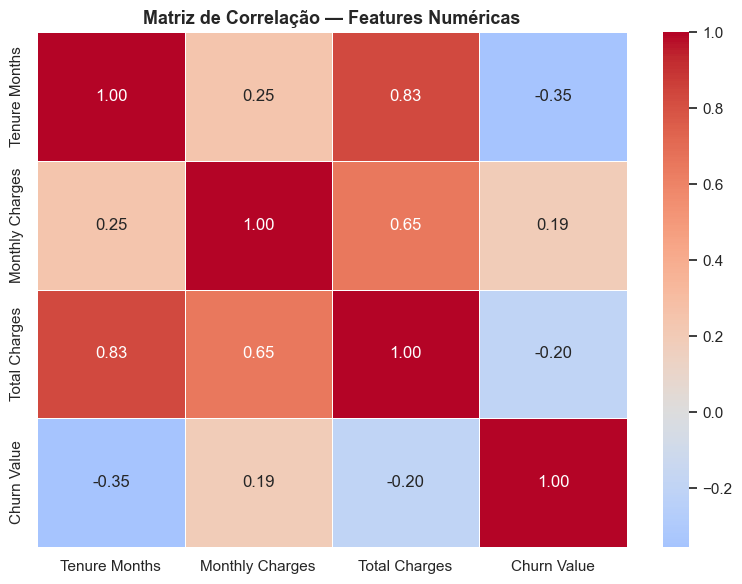

Correlação com Churn Value:


,Churn Value
Tenure Months,-0.354049
Total Charges,-0.199484
Monthly Charges,0.192858


In [17]:
# Selecionando apenas as colunas numéricas para o heatmap
numeric_cols = ["Tenure Months", "Monthly Charges", "Total Charges", "Churn Value"]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,          # exibe o valor de correlação em cada célula
    fmt=".2f",
    cmap="coolwarm",     # azul = correlação negativa, vermelho = positiva
    center=0,
    linewidths=0.5,
    ax=ax,
)

ax.set_title("Matriz de Correlação — Features Numéricas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Correlação de cada feature com o target, ordenada
print("Correlação com Churn Value:")
display(
    corr_matrix["Churn Value"]
    .drop("Churn Value")
    .sort_values(key=abs, ascending=False)
    .to_frame()
    .style.background_gradient(cmap="coolwarm", axis=0)
)


### Observações — Correlação

| Par | Correlação | Interpretação |
|-----|-----------|---------------|
| `Total Charges` × `Tenure Months` | ~0.83 | **Alta multicolinearidade** — confirmando a análise anterior |
| `Total Charges` × `Monthly Charges` | ~0.65 | Correlação moderada-alta |
| `Tenure Months` × `Churn Value` | ~-0.35 | Quanto mais tempo de contrato, menor o churn |
| `Monthly Charges` × `Churn Value` | ~+0.19 | Mensalidade mais alta associada a maior churn |
| `Total Charges` × `Churn Value` | ~-0.20 | Efeito dominado pelo Tenure |

**Decisão para a modelagem:**
- Considerar **remover `Total Charges`** no pipeline de pré-processamento, pois é derivável de `Tenure Months × Monthly Charges`
- Para a Regressão Logística, aplicar **regularização L2** (padrão do sklearn) para mitigar a multicolinearidade
- Para o MLP, manter todas as features — redes neurais são mais robustas à multicolinearidade
